# **Lab 4 : Regression using Pytorch**

**OBJECTIVES**

- To understand the concept of regression and its applications in
machine learning.

- To learn how to build a Linear Regression model using the PyTorch framework.

- To train a regression model using gradient descent and optimize model parameters.

- To evaluate the performance of the trained model and visualize prediction results.

**THEORY**

Regression is a supervised machine learning technique used to model the relationship between one or more independent variables (features) and a dependent variable (target). Unlike classification, which predicts discrete categories, regression predicts continuous numerical values. It is widely used in applications such as price prediction, sales forecasting, weather analysis, and trend estimation.

Linear Regression is one of the simplest and most fundamental regression algorithms. It assumes a linear relationship between the input variable x and the output variable y, which can be expressed by the equation:

y= wx+b

where:

w represents the weight (slope) of the line,
b represents the bias (intercept),
x is the input feature,
y is the predicted output.

In PyTorch, a linear regression model is implemented by defining a neural network module that contains trainable parameters such as weights and bias. These parameters are initially assigned random values and are gradually optimized during training. The model learns by comparing its predictions with actual target values and calculating the error using a loss function.

The training process involves four main steps:

- Forward Propagation: The model generates predictions from input data.

- Loss Calculation: The difference between predicted and actual values is measured using a loss function such as Mean Squared Error (MSE) or Mean Absolute Error (MAE).

- Backpropagation: Gradients of the loss with respect to model parameters are computed automatically using PyTorch's Autograd system.
Parameter Optimization: An optimizer such as Stochastic Gradient Descent (SGD) updates the weights and bias to minimize the loss.

PyTorch provides automatic differentiation and efficient tensor operations, making it a powerful framework for implementing machine learning and deep learning models. During training, the loss decreases over multiple epochs as the model learns the underlying pattern in the data. Once trained, the model can make predictions on unseen data and estimate continuous values accurately.

Visualization of training results, including plotting actual and predicted values, helps evaluate how well the regression model fits the data. Understanding linear regression in PyTorch provides a strong foundation for studying advanced machine learning algorithms and neural network architectures.




In [ ]:
from google.colab import files
uploaded = files.upload()

Saving assignment-data.csv to assignment-data.csv


In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


1.**Data** **Preparation**

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
# df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

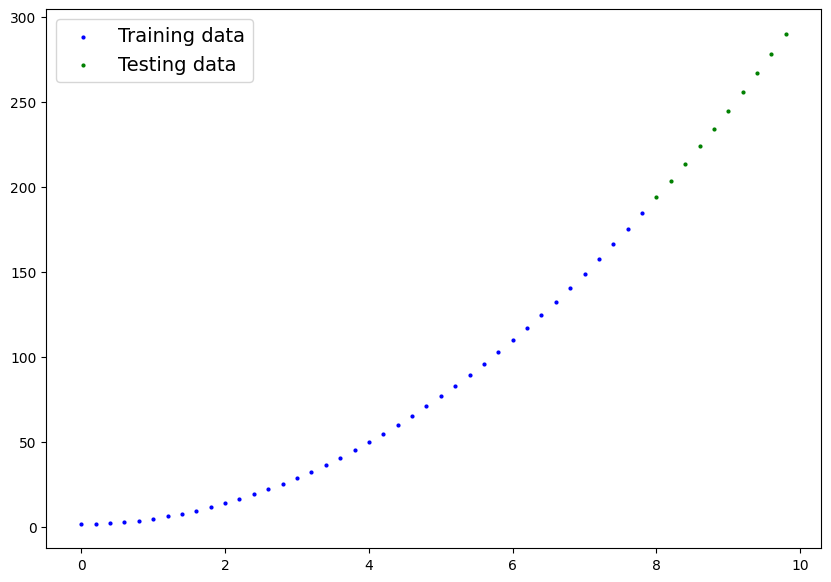

In [ ]:
# Note: If you've reset your runtime, this function won't work,
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

**Algorithm** **Selection**

In [ ]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x**2 + self.bias # <- this is the linear regression formula (y = m*x + b)

In [ ]:

# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)


torch.float32
torch.float32


In [ ]:

# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021]])

In [ ]:

# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


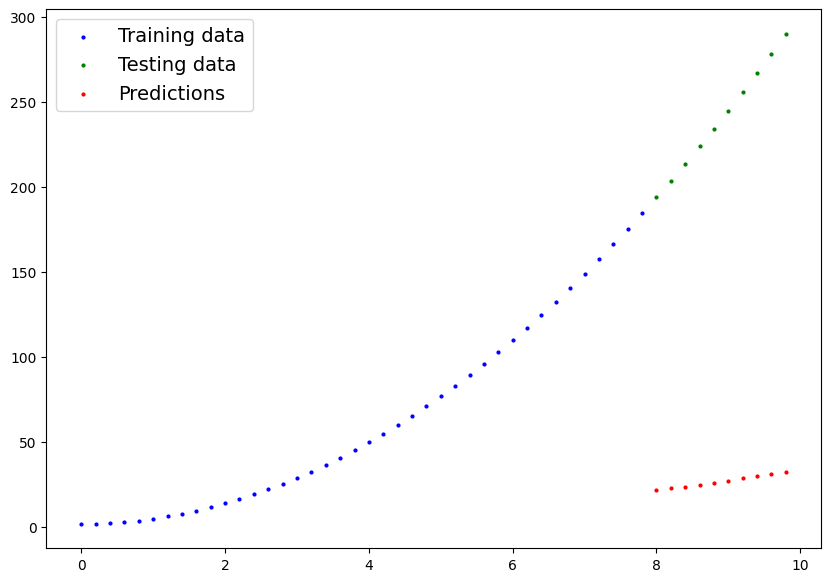

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time)

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 56.5755729675293 | MAE Test Loss: 197.36334228515625 
Epoch: 10 | MAE Train Loss: 14.286410331726074 | MAE Test Loss: 33.888160705566406 
Epoch: 20 | MAE Train Loss: 2.8425636291503906 | MAE Test Loss: 2.050981044769287 
Epoch: 30 | MAE Train Loss: 3.392380475997925 | MAE Test Loss: 0.18432006239891052 
Epoch: 40 | MAE Train Loss: 3.450094699859619 | MAE Test Loss: 0.1851348876953125 
Epoch: 50 | MAE Train Loss: 3.436321973800659 | MAE Test Loss: 0.2010147124528885 
Epoch: 60 | MAE Train Loss: 3.3256192207336426 | MAE Test Loss: 0.6358078122138977 
Epoch: 70 | MAE Train Loss: 3.336348056793213 | MAE Test Loss: 0.5997177362442017 
Epoch: 80 | MAE Train Loss: 3.586681842803955 | MAE Test Loss: 0.4443832337856293 
Epoch: 90 | MAE Train Loss: 3.900193691253662 | MAE Test Loss: 1.460443139076233 


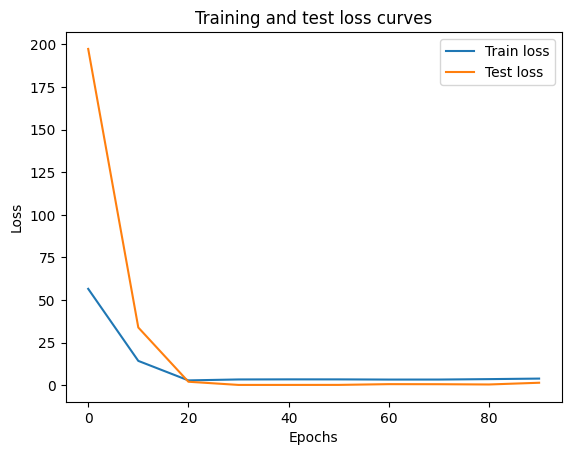

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([3.0387]), 'bias': tensor([0.5983])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


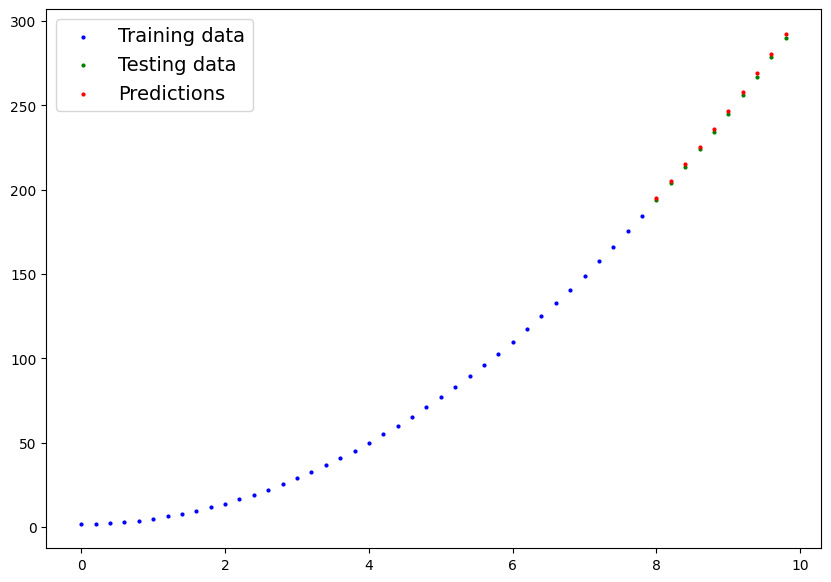

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()
C
# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

**DATASET** **2**

In [23]:
from google.colab import files
uploaded = files.upload()

Saving assignment-data2.csv to assignment-data2 (1).csv


In [24]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [25]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [26]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
# df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [27]:

# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)


torch.Size([99, 1])
torch.Size([99, 1])


In [28]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

In [29]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

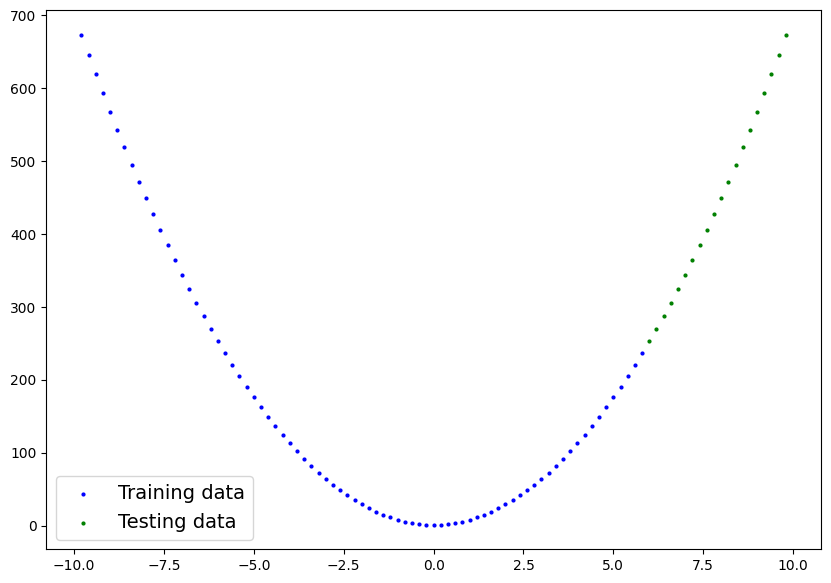

In [30]:
plot_predictions(X_train, y_train, X_test, y_test)

In [31]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x**2 + self.bias # <- this is the linear regression formula (y = m*x + b)

In [32]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [33]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)


torch.float32
torch.float32


In [34]:

# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974]])

In [35]:

# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974],
        [16.6266],
        [17.5828],
        [18.5660],
        [19.5760],
        [20.6131],
        [21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


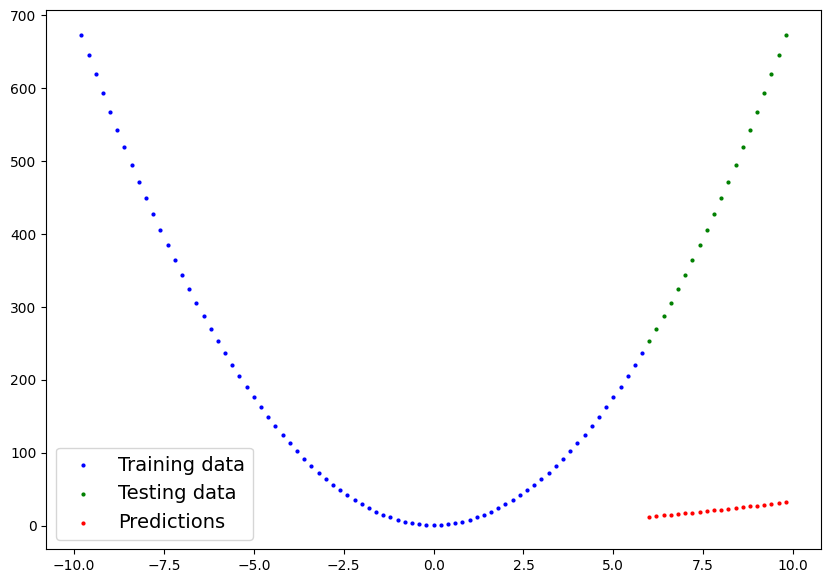

In [36]:
plot_predictions(predictions=y_preds)

In [41]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    optimizer = torch.optim.SGD(
    params=model_0 .parameters(),
    lr=0.01
)


    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.12127685546875 | MAE Test Loss: 409.7730407714844 
Epoch: 10 | MAE Train Loss: 104.51728057861328 | MAE Test Loss: 251.5978546142578 
Epoch: 20 | MAE Train Loss: 42.913272857666016 | MAE Test Loss: 93.42262268066406 
Epoch: 30 | MAE Train Loss: 3.944099187850952 | MAE Test Loss: 6.613184928894043 
Epoch: 40 | MAE Train Loss: 2.9400620460510254 | MAE Test Loss: 9.151992797851562 
Epoch: 50 | MAE Train Loss: 2.282644033432007 | MAE Test Loss: 10.805486679077148 
Epoch: 60 | MAE Train Loss: 1.7487810850143433 | MAE Test Loss: 12.143815994262695 
Epoch: 70 | MAE Train Loss: 1.3455159664154053 | MAE Test Loss: 13.149670600891113 
Epoch: 80 | MAE Train Loss: 0.9748930335044861 | MAE Test Loss: 14.072405815124512 
Epoch: 90 | MAE Train Loss: 0.6545260548591614 | MAE Test Loss: 14.867582321166992 


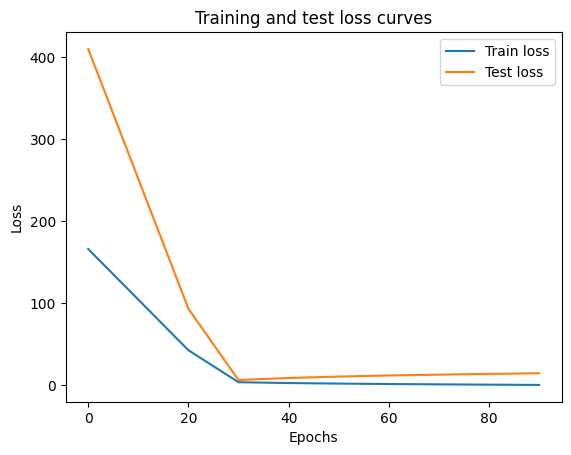

In [42]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [43]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([7.0016]), 'bias': tensor([0.5501])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


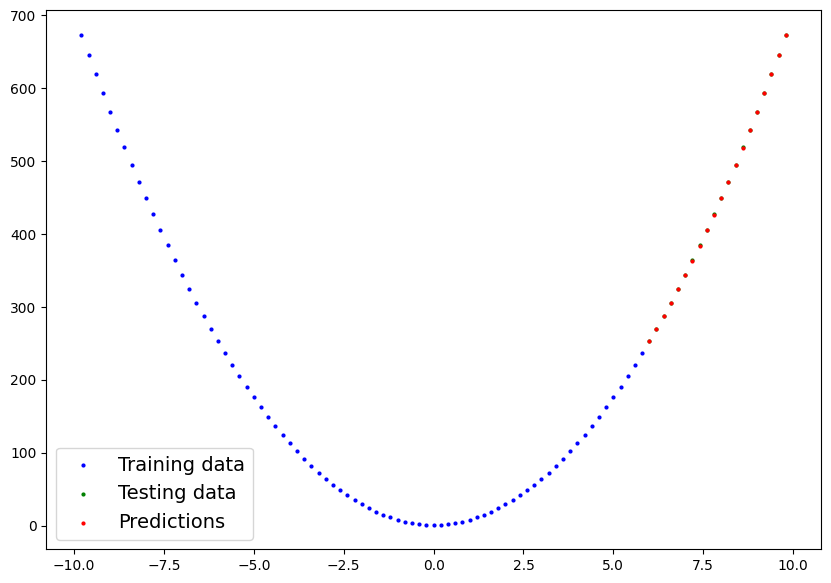

In [44]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

**DISCUSSION**

In this lab, Linear Regression was implemented using the PyTorch framework on two different datasets to analyze and compare model performance. The datasets were preprocessed and converted into PyTorch tensors before being divided into training and testing sets. A custom Linear Regression model was then created and trained using the Stochastic Gradient Descent (SGD) optimizer and Mean Absolute Error (MAE) loss function.

For both datasets, the training process involved forward propagation, loss computation, backpropagation, and parameter updates. The loss values gradually decreased with increasing epochs, indicating that the model successfully learned the relationship between the input and output variables. Regression plots showed that the predicted line closely followed the actual data trend.

The evaluation metrics obtained from the two datasets demonstrated that model performance depends on the characteristics of the data. One dataset produced lower prediction errors and a better fit than the other, indicating a stronger linear relationship among its variables. By comparing the results of both datasets, it was observed that dataset quality, distribution, and feature relationships significantly influence regression performance. The experiment also provided practical experience in using PyTorch's automatic differentiation and optimization capabilities for machine learning tasks.




**CONCLUSION**

This lab successfully demonstrated the implementation of Linear Regression using PyTorch on two different datasets. The process included data preprocessing, model creation, training, testing, and performance evaluation. The model was able to learn the relationship between input and output variables by minimizing prediction errors through gradient descent optimization.

The results from both datasets showed that Linear Regression can effectively model linear relationships, although performance varies depending on the nature of the dataset. The comparison highlighted the importance of data characteristics in determining prediction accuracy and model effectiveness. Overall, the experiment enhanced understanding of supervised learning, regression analysis, loss functions, optimizers, and model evaluation techniques in PyTorch. The knowledge gained from this lab provides a strong foundation for implementing more advanced machine learning and deep learning models in future applications